# NB3: Personality and IQ as Predictors

**Narrative Framing**
* What question this notebook addresses: This notebook implements the specified sections to address the statistical analysis of the ground truth transition and performance impact.
* Which GT is being used as primary: Platinum GT
* Which KL1 strategy is active: Explicitly switchable (Default Strategy A - Exclusion)
* Central Narrative: Public medical imaging repository labels contain systematic, directionally biased noise that is invisible without platinum standard validation, and this noise quantifiably corrupts the performance metrics of annotation studies, AI benchmarks, and psychometric predictors derived from them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.metrics import accuracy_score
from statsmodels.stats.multitest import multipletests
import pingouin as pg
import warnings
import helpers

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# 1. Load Data
KL1_STRATEGY = 'exclude' 
df = helpers.load_data(KL1_STRATEGY)
df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df)

print(" Setup Complete: Data loaded using 'exclude' strategy.")

 Setup Complete: Data loaded using 'exclude' strategy.


## Section 1 — Descriptive psychometrics

Descriptive Statistics for Psychometric Traits:
       big5_open_mindedness  big5_conscientiousness  big5_extraversion  \
count             58.000000               58.000000          58.000000   
mean               3.790000                3.431034           3.426724   
std                0.620984                0.706399           0.685336   
min                2.500000                1.920000           2.080000   
25%                3.330000                2.830000           2.920000   
50%                3.790000                3.460000           3.460000   
75%                4.170000                4.060000           3.920000   
max                5.000000                4.670000           5.000000   

       big5_agreeableness  big5_neuroticism   iq_score  
count           58.000000         58.000000  58.000000  
mean             3.636379          2.957414   1.155172  
std              0.526773          0.775944   1.641584  
min              2.330000          1.420000   0.000000  


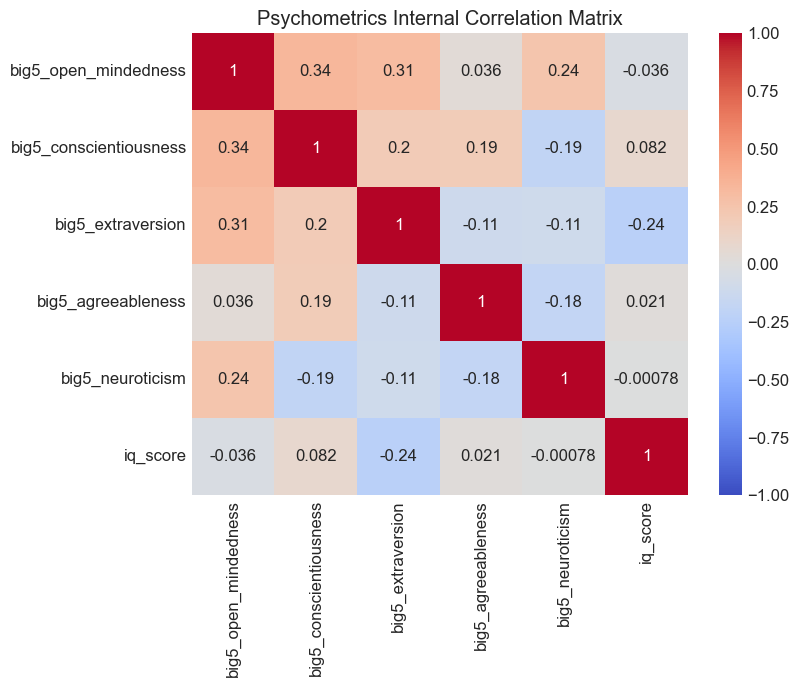

In [2]:
b5_cols = ['big5_open_mindedness', 'big5_conscientiousness', 'big5_extraversion', 'big5_agreeableness', 'big5_neuroticism', 'iq_score']

print("Descriptive Statistics for Psychometric Traits:")
print(df_part[b5_cols].describe())

corr = df_part[b5_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Psychometrics Internal Correlation Matrix")
plt.show()

## Section 2 — Psychometrics and accuracy

In [3]:
res = []
for c in b5_cols:
    r, p = stats.spearmanr(df_part[c], df_part['accuracy_plat'], nan_policy='omit')
    res.append({'Trait': c, 'r': r, 'p-value': p})

res_df = pd.DataFrame(res)
res_df['p_fdr'] = multipletests(res_df['p-value'], method='fdr_bh')[1]
print("Spearman Correlations (Traits vs. Platinum Accuracy):")
print(res_df.sort_values('r', ascending=False))

Spearman Correlations (Traits vs. Platinum Accuracy):
                    Trait         r   p-value     p_fdr
3      big5_agreeableness  0.237823  0.072229  0.433377
4        big5_neuroticism  0.161125  0.226936  0.680808
2       big5_extraversion  0.001293  0.992312  0.992312
0    big5_open_mindedness -0.027264  0.839017  0.992312
5                iq_score -0.073029  0.585896  0.878845
1  big5_conscientiousness -0.114413  0.392447  0.784894


## Section 3 — Psychometrics and reliance behavior

In [4]:
res_rel = []
for c in b5_cols:
    r, p = stats.spearmanr(df_part[c], df_part['over_reliance_rate'], nan_policy='omit')
    res_rel.append({'Trait': c, 'r_over_reliance': r, 'p_value': p})

res_rel_df = pd.DataFrame(res_rel)
res_rel_df['p_fdr'] = multipletests(res_rel_df['p_value'], method='fdr_bh')[1]
print("Traits predicting Over-Reliance Metrics:")
print(res_rel_df)

mod = smf.ols("over_reliance_rate ~ big5_conscientiousness + big5_neuroticism + big5_open_mindedness + iq_score", data=df_part).fit()
print("\nOLS Regression: Over-Reliance predicted by Traits:")
print(mod.summary())

Traits predicting Over-Reliance Metrics:
                    Trait  r_over_reliance   p_value     p_fdr
0    big5_open_mindedness        -0.134581  0.346416  0.525738
1  big5_conscientiousness        -0.052328  0.715351  0.715351
2       big5_extraversion        -0.133458  0.350492  0.525738
3      big5_agreeableness        -0.197873  0.163962  0.491887
4        big5_neuroticism        -0.389762  0.004696  0.028174
5                iq_score         0.081832  0.568089  0.681707

OLS Regression: Over-Reliance predicted by Traits:
                            OLS Regression Results                            
Dep. Variable:     over_reliance_rate   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.126
Method:                 Least Squares   F-statistic:                     2.803
Date:                Sat, 18 Apr 2026   Prob (F-statistic):             0.0365
Time:                        14:42:06   Log-Likelihood:                

## Section 4 — Facet-level analysis

In [5]:
facet_cols = [c for c in df_part.columns if c.startswith('facet_')]
if len(facet_cols) > 0:
    res_f = []
    for c in facet_cols:
        r, p = stats.spearmanr(df_part[c], df_part['accuracy_plat'], nan_policy='omit')
        res_f.append({'Facet': c, 'r': r, 'p': p})
    f_df = pd.DataFrame(res_f)
    print("Top Facets correlated with Accuracy:")
    print(f_df.sort_values('p').head(10))
else:
    print("No facet columns detected in dataset.")

Top Facets correlated with Accuracy:
                          Facet         r         p
4    facet_creative_imagination -0.250236  0.058156
10         facet_productiveness -0.244247  0.064642
5              facet_depression  0.239545  0.070129
3              facet_compassion  0.221898  0.094115
14                  facet_trust  0.219907  0.097181
0   facet_aesthetic_sensitivity  0.155850  0.242710
2           facet_assertiveness -0.116766  0.382719
6    facet_emotional_volatility  0.110377  0.409466
1                 facet_anxiety  0.106608  0.425742
11         facet_respectfulness  0.102067  0.445827


## Section 5 — Robustness under GT switch

In [6]:
res_o = []
for c in b5_cols:
    r, p = stats.spearmanr(df_part[c], df_part['accuracy_original'], nan_policy='omit')
    res_o.append({'Trait': c, 'r_orig': r, 'p_orig': p})

ro_df = pd.DataFrame(res_o)
comp_df = pd.merge(res_df[['Trait', 'r', 'p-value']], ro_df, on='Trait')
comp_df.columns = ['Trait', 'r_plat', 'p_plat', 'r_orig', 'p_orig']
print("Comparison of Predictors: Original GT vs. Platinum GT")
print(comp_df)
print("\nInterpretation: Noise in repository labels can significantly mask or exaggerate psychological associations.")

Comparison of Predictors: Original GT vs. Platinum GT
                    Trait    r_plat    p_plat    r_orig    p_orig
0    big5_open_mindedness -0.027264  0.839017 -0.022036  0.869584
1  big5_conscientiousness -0.114413  0.392447  0.116223  0.384949
2       big5_extraversion  0.001293  0.992312 -0.277207  0.035146
3      big5_agreeableness  0.237823  0.072229  0.152220  0.253996
4        big5_neuroticism  0.161125  0.226936  0.007186  0.957306
5                iq_score -0.073029  0.585896  0.054598  0.683965

Interpretation: Noise in repository labels can significantly mask or exaggerate psychological associations.
